In [49]:
import modal
from modal_colabfold import generate_a3m_files
import pandas as pd
from binder_design import EGFS, FOLD_RESULTS_DIR, PEPMLM_RESULTS_DIR, DATA_DIR
from binder_design.utils import get_mutation_diff, hash_seq
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import re
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:


csvs = list(PEPMLM_RESULTS_DIR.glob('*.csv'))
dfs = []
for csv in csvs:
    _df = pd.read_csv(csv)
    match = re.search(r'gen(\d+)', str(csv))
    if match:
        gen_num = int(match.group(1))
    else:
        gen_num = None
    _df['generation'] = gen_num
    dfs.append(_df)
pepmlm_df = pd.concat(dfs).sort_values('unmasked_ppl').reset_index(drop=True)

In [51]:
fold_csvs = list(FOLD_RESULTS_DIR.glob('*.csv'))
fold_df = pd.concat([pd.read_csv(csv) for csv in fold_csvs]).sort_values('pae_interaction').reset_index(drop=True)

In [52]:
merged = fold_df.merge(pepmlm_df, on='seq_id', how='left')

<Axes: xlabel='pae_interaction', ylabel='unmasked_ppl'>

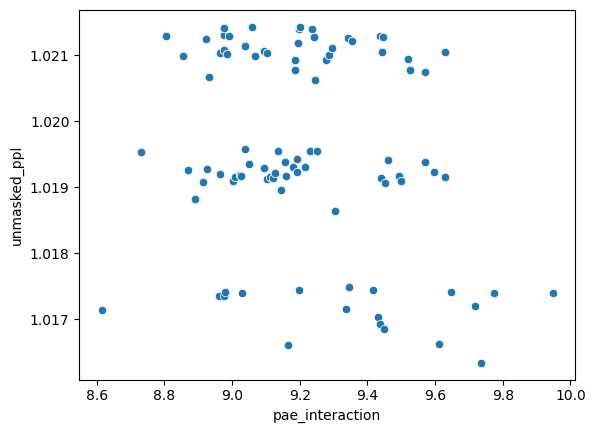

In [53]:
sns.scatterplot(x='pae_interaction', y='unmasked_ppl', data=merged.query('pae_interaction < 10'))

In [25]:
fdf = pd.read_csv('/Users/alex/code/binder_design/data/fold_results/fold_results_20240818_131538.csv')

In [27]:
fdf

,seq_name,binder_sequence,target_sequence,binder_length,target_length,model_number,binder_plddt,binder_pae,pae_interaction,ptm,seq_id,pdb_content,generation
0,823045,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCRCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.7722,4.294548,8.806252,0.85,823045,MODEL 1 ...,1
1,f01425,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVKGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.5664,4.351644,8.922027,0.84,f01425,MODEL 1 ...,1
2,8a1d35,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.1970,4.483808,8.975793,0.85,8a1d35,MODEL 1 ...,1
3,ed316e,NSYPGCPSSYDGYCGNGGVCMHIESLDSYTCNCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.2188,4.291372,8.976084,0.84,ed316e,MODEL 1 ...,1
4,61f690,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVIGRSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.3284,4.342752,8.977805,0.84,61f690,MODEL 1 ...,1
5,390d84,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVHGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.0936,4.456312,8.990946,0.84,390d84,MODEL 1 ...,1
6,7affbc,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCKCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.9732,4.506532,9.037587,0.84,7affbc,MODEL 1 ...,1
7,c3c32d,NSYPGCPSSYDGYCLNGGVCAHIESLDSYTCNCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.9724,4.462116,9.058826,0.84,c3c32d,MODEL 1 ...,1
8,d18e97,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVPGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.8876,4.425756,9.093736,0.84,d18e97,MODEL 1 ...,1
9,4daa51,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVIGYSGDRVQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.6272,4.454456,9.195722,0.84,4daa51,MODEL 1 ...,1


In [28]:
fdf['mut_str'] = fdf['binder_sequence'].apply(get_mutation_diff, seq2=EGFS)

In [29]:
fdf

,seq_name,binder_sequence,target_sequence,binder_length,target_length,model_number,binder_plddt,binder_pae,pae_interaction,ptm,seq_id,pdb_content,generation,mut_str
0,823045,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCRCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.7722,4.294548,8.806252,0.85,823045,MODEL 1 ...,1,R32N
1,f01425,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVKGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.5664,4.351644,8.922027,0.84,f01425,MODEL 1 ...,1,K35I
2,8a1d35,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.1970,4.483808,8.975793,0.85,8a1d35,MODEL 1 ...,1,K50W
3,ed316e,NSYPGCPSSYDGYCGNGGVCMHIESLDSYTCNCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.2188,4.291372,8.976084,0.84,ed316e,MODEL 1 ...,1,G15L
4,61f690,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVIGRSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.3284,4.342752,8.977805,0.84,61f690,MODEL 1 ...,1,R37Y
5,390d84,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVHGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,87.0936,4.456312,8.990946,0.84,390d84,MODEL 1 ...,1,H35I
6,7affbc,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCKCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.9732,4.506532,9.037587,0.84,7affbc,MODEL 1 ...,1,K32N
7,c3c32d,NSYPGCPSSYDGYCLNGGVCAHIESLDSYTCNCVIGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.9724,4.462116,9.058826,0.84,c3c32d,MODEL 1 ...,1,A21M
8,d18e97,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVPGYSGDRCQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.8876,4.425756,9.093736,0.84,d18e97,MODEL 1 ...,1,P35I
9,4daa51,NSYPGCPSSYDGYCLNGGVCMHIESLDSYTCNCVIGYSGDRVQTRD...,LEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYV...,50,622,1,86.6272,4.454456,9.195722,0.84,4daa51,MODEL 1 ...,1,V42C
